# Homework 3  
# Regression models

# <p style="text-align: right;"> &#9989; Ethan Belanger</p>
# <p style="text-align: right;"> &#9989; ethanb524.</p>

# Goal for this homework assignment
By now, you have learned a bit about regression models. In this assignment, you will practice:

* Using branches in Git
* Performing linear regression
* Performing multiple regression
* Performing logistic regression
* Creating a project timeline

**This assignment is due by 11:59 pm on Friday, July 24th.** It should be uploaded into the "Homework Assignments" submission folder for Homework 3.  Submission instructions can be found at the end of the notebook. **There are 71 standard points possible in this assignment, including points for Git commits/pushes. The distribution of points can be found in the section headers**.


---
<a id="toc"></a>

## Table of contents

* [Part 1: Git branch](#part1) (6 points)

* [Part 2: Simple linear regression](#part2) (24 points)

* [Part 3: Multiple regression](#part3) (14 points)

* [Part 4: Logistic regression](#part4) (18 points)

* [Part 5: Project planning](#part5) (5 points)

* [Part 6: Assignment wrap-up](#part6) (4 points)


##### Run this cell below before moving on:

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import StackGP as sgp
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


sns.set_context("talk")

---
[Back to ToC](#toc)
<a name="part1"></a>
# Part 1: Git Branch (6 points) 


You're going to add this assignment to the `cmse202-S26-turnin` repository you created so that you can track your progress on the assignment and preserve the final version that you turn in. You will do this by performing the tasks 1.1 - 1.6 below.

**Important**: Double-check you've added your Professor and your TA as collaborators to your "turnin" repository (you should have done this in the HW01 assignment).

**Also important**: Make sure that the version of this notebook that you are working on is the same one that you just added to your repository! If you are working on a different copy of the notebook, **none of your changes will be tracked**!

**&#9989; Question 1.1 (1 point)**: Navigate to your `cmse202-S26-turnin` **local** repository and create a new directory called `hw-03`. In the cell below put the command(s) you used to do this.

<font size=6 color="#009600">&#9998;</font> mkdir hw-03

**&#9989; Question 1.2 (1 point)**: Move this notebook into that **new directory** in your repository, but **do not** add or commit it to your repository yet. Put the command(s) you used to do this in the cell below.

<font size=6 color="#009600">&#9998;</font> mv HW-03_Regression-U26-STUDENT.ipynb /home/belan122/CMSE202/Notebooks/CMSE202-f25-turnin/hw-03

**&#9989; Question 1.3 (1 point)**: Create a **new branch** called `hw03_branch` (The Day 17 PCA and ICA content has information on how to do this). Put the command(s) you used to do this in the cell below.

<font size=6 color="#009600">&#9998;</font> git branch hw03_branch

**&#9989; Question 1.4 (1 point)**: "Check out" the new branch (so that you'll be working on that branch). Put the command(s) you used to do this in the cell below.

<font size=6 color="#009600">&#9998;</font> git checkout hw03_branch

**&#9989; Question 1.5 (1 point)**:  Double check to make sure you are actually on that branch. Put the command(s) you used to do this in the cell below.

<font size=6 color="#009600">&#9998;</font> git branch

**&#9989; Question 1.6 (1 point)**: Once you're certain you're working on your new branch, add this notebook to your repository, then make a commit and push it to GitHub. You may need to use `git push origin hw03_branch` to push your new branch to GitHub. Put the command(s) you used to do this in the cell below.

<font size=6 color="#009600">&#9998;</font> git add HW-03_Regression-U26-STUDENT.ipynb
git commit -m "adding HW 03"
git push origin hw03_branch

---
If everything went as intended, the file should now show up on your GitHub account in the "`cmse202-S26-turnin`" repository inside the `hw-03` directory that you just created within the new branch `hw03-branch`.

Periodically, **you'll be asked to commit your changes to the repository and push them to the remote GitHub location**. Of course, you can always commit your changes more often than that, if you wish.  It can be good to get into a habit of committing your changes any time you make a significant modification, or when you stop working on the problems for a bit.

&#9989; **Do this:  Remember to do every Git commit/push mentioned throughout the assignment!**


---
<a name="part2"></a>
[Back to ToC](#toc)

# Part 2: One Variable (Linear) Regression (24 points)

In this part, we'll perform some one-variable linear regression analysis on the supplied "Train_1.csv" dataset which we will download.



&#9989;  **Question 2.1 (1 points)**: **Do This:** Download the file `Train_1.csv` from the link below, and save it into the same directory as your notebook. **Then, in the cell below, put the command line command(s) you used to download the file.** If you did not use a command line tool to download the file, write down the command(s) that would have downloaded the file.

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/Train_1.csv`

``` bash
# curl -O https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/Train_1.csv
```

&#9989;  **Question 2.2 (2 points)**: Next, load the data using Pandas and save it into a data frame called `train_data`. Then display the entire dataframe.

In [3]:
# Put your code here
Train = pd.read_csv("Train_1.csv")
Train.head()

,X,Y
0,1.443389,0.140771
1,1.811505,0.077327
2,2.970240,0.004844


&#9989;  **Question 2.3 (2 points)**: How many rows and columns are in this data set? What are you thoughts on this? 

<font size=6 color="#009600">&#9998;</font> There are three rows and two columns, which makes me wonder if there's a large enough sample size for this data to be statistically significant.

 &#9989; **Question 2.4 (5 points)**: Using the `OLS()` method in `statsmodels.api`, make a simple linear regression model that predicts "Y" using "X" as the independent variable. Be sure to use the `add_constant()` method to add a column of ones to the DataFrame before using the `OLS()` method so that your linear model includes a constant term. Display the fitting summary once you have fit the model. 

In [4]:
# Put your code here
X = Train["X"]
Y = Train["Y"]
X = sm.add_constant(X)
model = sm.OLS(Y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     15.07
Date:                Sat, 25 Jul 2026   Prob (F-statistic):              0.161
Time:                        16:20:20   Log-Likelihood:                 8.5809
No. Observations:                   3   AIC:                            -13.16
Df Residuals:                       1   BIC:                            -14.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2458      0.046      5.309      0.1

/opt/miniconda3/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


&#9989; **Question 2.5 (2 points):** Comment on the fit of your model. What are you using to judge the fit?

<font size=+3>&#9998;</font>  _Using the adjusted R^2 of 0.876, we see that this value suggests a strong fit._

&#9989; **Question 2.6 (4 points):** Plot the scatter plot of your independent and dependent data and also plot the line predicted by the regression. Include descriptive labels, titles, and legends as appropriate.

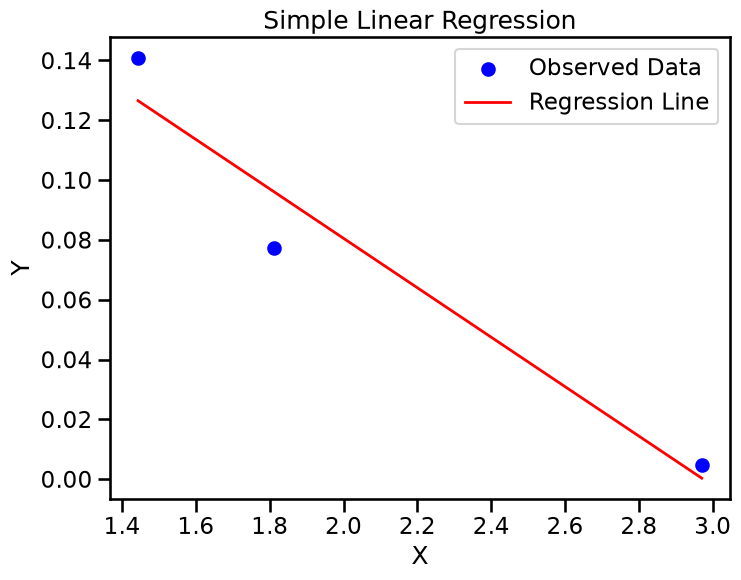

In [5]:
# Put your answer here
Y_pred = results.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(Train["X"], Y, color="blue", label="Observed Data")
plt.plot(Train["X"], Y_pred, color="red", linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

&#9989; **Question 2.7 (3 points):** Now download the test set `Test_1.csv` from the link below and save it into a dataframe named `test_data`. Once downloaded, split the data into features and labels and then add a constant to the features.  

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/Test_1.csv`

In [6]:
# Put your code here
Test = pd.read_csv("Test_1.csv")
X_test = Test["X"]
Y_test = Test["Y"]
X_test = sm.add_constant(X_test)
print(X_test.head())
print(Y_test.head())

   const         X
0    1.0  2.991302
1    1.0  2.979683
2    1.0  2.927876
3    1.0  2.887760
4    1.0  2.877399
0    0.004549
1    0.004709
2    0.005488
3    0.006167
4    0.006354
Name: Y, dtype: float64


&#9989; **Question 2.8 (4 points):** Make a scatter plot of your independent and dependent data from the test set, and also plot the line predicted by the new regression model on the test data. Include descriptive labels, titles, and legends as appropriate. 

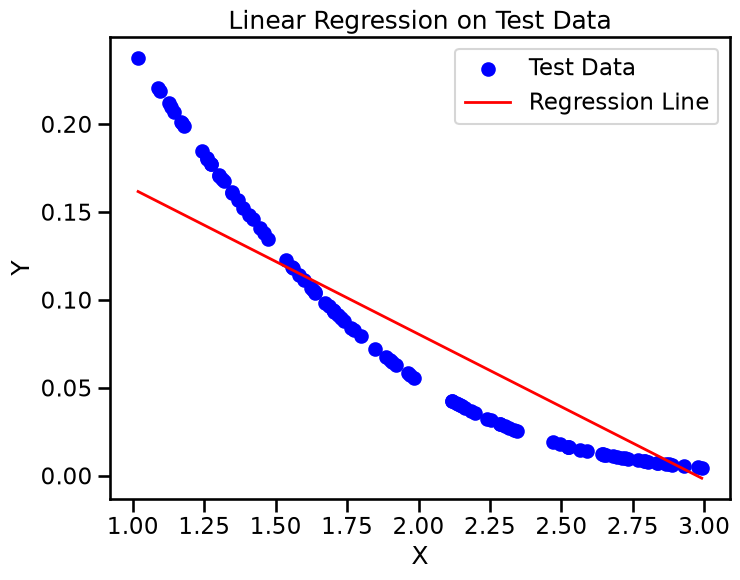

In [9]:
# Put your answer here
Y_test_pred = results.predict(X_test)
order = np.argsort(Test["X"])
plt.figure(figsize=(8,6))
plt.scatter(Test["X"], Y_test, color="blue", label="Test Data")
plt.plot(Test["X"].iloc[order], Y_test_pred.iloc[order], color="red", linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression on Test Data")
plt.legend()
plt.show()

&#9989; **Question 2.9 (1 point):** Comment on the fit of your model using the above plot. Do you think this is the right model for this data?

<font size=+3>&#9998;</font> _Put your answer here: It probably isn't since the points put together look like they could represent a non-linear function, meaning that a linear model shouldn't be used here.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 2 complete", and push the changes to GitHub.

---
<a name="part3"></a>
[Back to ToC](#toc)


# Part 3: Multiple Regression (14 points)
In this part, we will explore multivariable regression on the Computer Hardware dataset from the UCI Machine Learning Repository ([Data Link](https://archive.ics.uci.edu/dataset/29/computer+hardware)). 

Download a cleaned version of the data from here: https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/machine.csv

&#9989; **Question 3.1 (5 points)**: Using the `OLS()` method in `statsmodels.api`, make a multiple regression model that predicts `"PRP"` using the other variables, and display the `.summary()` of that process. Once downloaded be sure to add a constant to the dataset using `add_constant()`.

In [3]:
# Put your code here
import pandas as pd
import statsmodels.api as sm
machine_data = pd.read_csv("machine.csv")
y = machine_data["PRP"]
X = machine_data.drop(columns=["PRP"])
X = sm.add_constant(X)
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    PRP   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     215.5
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           6.24e-85
Time:                        16:38:27   Log-Likelihood:                -1148.7
No. Observations:                 209   AIC:                             2311.
Df Residuals:                     202   BIC:                             2335.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -55.8939      8.045     -6.948      0.0

&#9989;  **Question 3.2 (2 points)**: Answer the following two questions: 

1. What is the R-squared value you got? 

2. Based on your R-squared value, what does it tell you about the regression fit, and how the model fits the data?

<font size=+3>&#9998;</font> _Put your answers here:
1. 0.865
2. It tells me that it's a strong, positive correlation, albeit not a perfect one.

&#9989;  **Question 3.3 (2 points)**: 
Based on the output of the OLS summary, do any of the features appear to be insignificant for predicting "PRP"? List any features that you would remove. 

<font size=+3>&#9998;</font> Put your answers here: Only CHMIN seems to be, so this is the only one I would remove.

&#9989;  **Question 3.4 (3 points)**: 
**Do This:** Design a second linear model without any features you determined were insignificant to predict the "median_house_value". 

In [4]:
# Put your code here
import statsmodels.api as sm
y = machine_data["PRP"]
X2 = machine_data.drop(columns=["PRP", "CHMIN"])
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2)
results2 = model2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                    PRP   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     259.7
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           3.86e-86
Time:                        16:44:11   Log-Likelihood:                -1148.7
No. Observations:                 209   AIC:                             2309.
Df Residuals:                     203   BIC:                             2330.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -56.0750      8.007     -7.003      0.0

&#9989;  **Question 3.5 (2 points)**: How did your reduced linear model fit the data compared to the full linear model you created in Question 4.1? Give some quantitative justification for this answer.

<font size=+3>&#9998;</font> The r^2 value remained the same, indicating that the fit was just as strong regardless of the changes.

---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 3 complete", and push the changes to GitHub.

---
<a name="part4"></a>
[Back to ToC](#toc)

# Part 4: Logistic Regression (18 points)

In this part, we will be using logistic regression to classify whether a person has diabetes or not. Logistic regression (as we've learned so far in class) does binary classification. 



&#9989;  **Question 4.1 (2 points)**: We will work with data originally from https://www.kaggle.com/datasets/aemyjutt/diabetesdataanslysis?select=diabetes.csv. 

**We will be using the cleaned version which can be downloaded from the link below**:

`https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/diabetes.csv`

**Do This**: In the cell below, type the code for downloading the data from inside your notebook and also code for loading the data into a pandas dataframe.

In [5]:
# Put your code here
import pandas as pd
url = "https://raw.githubusercontent.com/msu-cmse-courses/cmse202-supplemental-data/main/data/diabetes.csv"
diabetes_data = pd.read_csv(url)
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


&#9989;  **Question 4.2 (3 points)**:

Create a Pandas Series called `labels` which has data from the `Outcome` column of the DataFrame. Also, create a Pandas DataFrame called `features` which consists of just the columns `Glucose`, `BloodPressure`, `BMI`, and `Age`. Display the labels and features to make sure you did this correctly.

In [6]:
# Put your code here.
labels = diabetes_data["Outcome"]
features = diabetes_data[["Glucose", "BloodPressure", "BMI", "Age"]]
print(labels)
print(features)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64
     Glucose  BloodPressure   BMI  Age
0        148             72  33.6   50
1         85             66  26.6   31
2        183             64  23.3   32
3         89             66  28.1   21
4        137             40  43.1   33
..       ...            ...   ...  ...
763      101             76  32.9   63
764      122             70  36.8   27
765      121             72  26.2   30
766      126             60  30.1   47
767       93             70  30.4   23

[768 rows x 4 columns]


&#9989;  **Question 4.3 (5 points)**: Split your data into a training and testing set with a training set representing 80% of your data. For reproducibility, set the `random_state` argument to `541` (the 100th prime number!). Print the shapes of the training features, the testing features, the training labels, and the testing labels to show you have the right number of entries in each of the four variables.

In [7]:
# Put your code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=541
)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (614, 4)
Testing features: (154, 4)
Training labels: (614,)
Testing labels: (154,)


&#9989;  **Question 4.3 (4 points)**: Now, train a logistic regression model using your training features and training labels. Be sure to add a constant to the training features. **Display the summary**.

In [8]:
# Put your code here
import statsmodels.api as sm
X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_const)
results = logit_model.fit()
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.469670
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      609
Method:                           MLE   Df Model:                            4
Date:                Sat, 25 Jul 2026   Pseudo R-squ.:                  0.2724
Time:                        16:53:09   Log-Likelihood:                -288.38
converged:                       True   LL-Null:                       -396.34
Covariance Type:            nonrobust   LLR p-value:                 1.407e-45
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -8.7864      0.809    -10.859      0.000     -10.372      -7.201
Glucose           0.

&#9989;  **Question 4.4 (4 points)**: Finally, test your logistic regression model using your testing features and testing labels. Compute and display the accuracy score on the test data. 

In [9]:
# Put your code here
import statsmodels.api as sm
from sklearn.metrics import accuracy_score
X_test_const = sm.add_constant(X_test)
y_pred_prob = results.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6883116883116883


---
### &#128721; STOP
**Pause to commit your changes to your Git repository!**

Take a moment to save your notebook, commit the changes to your local `git` repository using the commit message "Part 4 complete", and push the changes to GitHub.

---

---
[Back to ToC](#toc)

<a name="part5"></a>
## Part 5. Setting a project timeline. (5 points)

You should know which project you will be working on with your group by now. You and your group will be presenting this project during the last week of class.  Come up with a project timeline with specific goals/checkpoints to meet as this deadline approaches.  The ability to set project timelines is a very useful skill to have professionally. You can create this timeline yourself or as a group. Try to, in the very least, create weekly checkpoints (~3). Write out your timeline below. 

<font size=+3>&#9998;</font> Put your timeline here:

---
<a name="conclusion"></a>
[Back to ToC](#toc)

## Part 6: Assignment wrap-up (4 points)


**6.1:** (1 point) Have you put **your name** and **GitHub username** at the top of your notebook?

**6.2:** (3 points) Now that you've finished your new "development" on your 202 turn-in repo, you can merge your work back into your `main` branch.

**&#9989; Do the following**:

1. Switch back to your `main` branch. 
2. Merge your `hw03_branch` with your `main` branch. 
3. Finally, push the changes to GitHub.

**NOTE:** The grader will be able to see your commit messages and whether you pushed the repo at this stage, if everything has gone as planned. Double-check that things look correct on **GitHub** before you submit this notebook to **D2L**.

---
## Congratulations, you're done!

Submit this assignment by uploading it to the course D2L web page.  Go to the "Homework Assignments" folder, find the dropbox link for Homework 3, and upload it there.

<img src=https://cdn.pixabay.com/animation/2025/08/11/04/05/04-05-10-511_512.gif>

*Dancing gif source: https://cdn.pixabay.com/animation/2025/08/11/04/05/04-05-10-511_512.gif

&#169; Copyright 2026,  Department of Computational Mathematics, Science and Engineering at Michigan State University